# CAPE demo

This notebook runs the native Rust/PyO3 CAPE extraction path on the official CAPE `Data/seq_example` frame from https://github.com/pedropro/CAPE/tree/master/Data/seq_example. Run `uv sync --all-extras` and `uv run maturin develop --release` before executing it.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
PYTHON_DIR = PROJECT_ROOT / "python"
if str(PYTHON_DIR) not in sys.path:
    sys.path.insert(0, str(PYTHON_DIR))

ARTIFACTS = PROJECT_ROOT / "artifacts"
ARTIFACTS.mkdir(exist_ok=True)

In [2]:
from cape_demo.official_data import load_official_seq_example
from cape_demo.visualization import save_demo_figure, overlay_labels

scene = load_official_seq_example(PROJECT_ROOT / "data" / "seq_example")
print(f"source={scene.source_dir}")
print(scene.depth.shape, scene.depth.dtype, scene.depth.min(), scene.depth.max())
print(scene.fx, scene.fy, scene.cx, scene.cy)


source=/home/inaho-omen/Project/cape_rs/data/seq_example
(480, 640) float64 0.0 6990.0
575.9268544880447 576.4079160109325 315.1502635638817 230.58580662101753


In [3]:
from cape_demo.extract import extract_frame

result = extract_frame(scene)
print("engine=cape_pyo3")
print(f"planes={len(result['planes'])}, cylinders={len(result['cylinders'])}")
print(result["stats"])


engine=cape_pyo3
planes=1, cylinders=1
{'height': 480, 'width': 640, 'grid_rows': 24, 'grid_cols': 32, 'planar_cells': 651, 'grown_segments': 7, 'skipped_small_segments': 5}


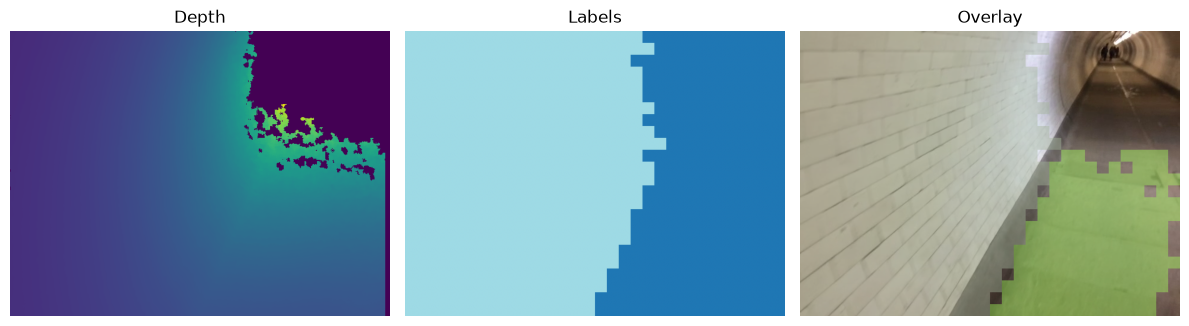

In [4]:
import matplotlib.pyplot as plt
import numpy as np

preview_path = save_demo_figure(scene, result, ARTIFACTS / "demo_preview.png")

fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(1, 3, 1)
ax1.imshow(scene.depth, cmap="viridis")
ax1.set_title("Depth")
ax1.axis("off")

ax2 = fig.add_subplot(1, 3, 2)
ax2.imshow(np.asarray(result["labels"]), cmap="tab20")
ax2.set_title("Labels")
ax2.axis("off")

ax3 = fig.add_subplot(1, 3, 3)
ax3.imshow(overlay_labels(scene.rgb, np.asarray(result["labels"])))
ax3.set_title("Overlay")
ax3.axis("off")
plt.tight_layout()


In [5]:
from pprint import pprint
print("Planes")
pprint(result["planes"])
print("Cylinders")
pprint(result["cylinders"])

Planes
[{'cell_count': 163,
  'd': 1364.1342270962648,
  'id': 1,
  'mean': [807.8777423259135, 471.318694838395, 2522.1922125789533],
  'mse': 211.58492669223196,
  'normal': [-0.04036155530097352, -0.9346513033789752, -0.3532674425214834],
  'point_count': 63487,
  'score': 381.2538622285095}]
Cylinders
[{'axis': [0.2990455155613242, -0.31885854306725886, 0.8993892422837216],
  'cell_count': 465,
  'center': [649.0501616858577, 418.97007762150696, -67.27159814999428],
  'extrusion_score': 648.9961848430968,
  'id': 1000,
  'mse': 6167.987447342235,
  'radius': 1422.5219260693573}]
